<a href="https://colab.research.google.com/github/thenairobi1/DeepLearning/blob/main/MLP_from_stratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Multilayer Perceptron (MLP) From Scratch
This notebook walks through building, training, and evaluating a **Multilayer Perceptron (MLP)** from scratch using only **NumPy**.

---

##  Objectives
1. Understand the theoretical architecture of feedforward neural networks.
2. Derivation and implementation of **Forward Propagation**.
3. Mathematical breakdown of **Loss Functions** (Binary Cross-Entropy / Mean Squared Error).
4. Derivation and implementation of **Backpropagation** using the Chain Rule.
5. Parameter updates via **Gradient Descent**.

In [1]:
import kagglehub

path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv


In [2]:
mkdir -p ~/.kaggle && echo KGAT_ec49ddc0a20048cee556d30bb22ba9d0 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [3]:
!kaggle datasets download -d oddrationale/mnist-in-csv
!unzip -q mnist-in-csv.zip

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
mnist-in-csv.zip: Skipping, found more recently modified local copy (use --force to force download)
replace mnist_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

28*28 pixels


In [13]:
import pandas as pd
import numpy as np
train = pd.read_csv('mnist_train.csv')
train.head()
train.shape

(60000, 785)

In [14]:
train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


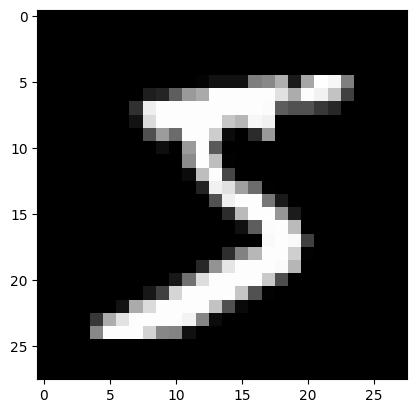

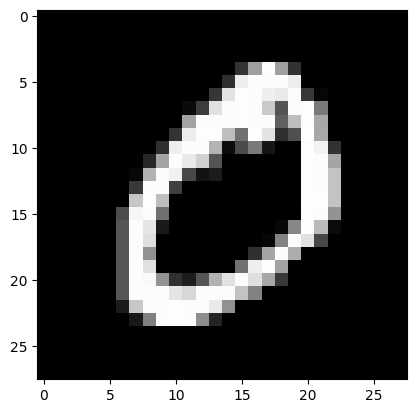

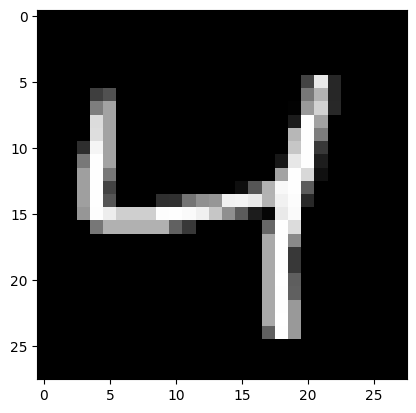

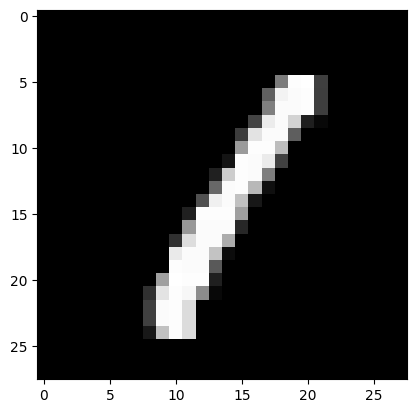

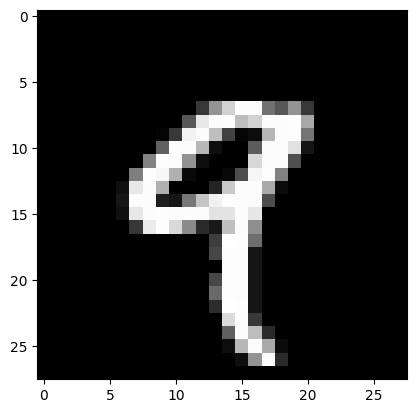

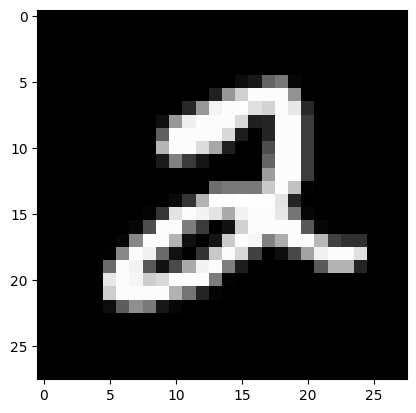

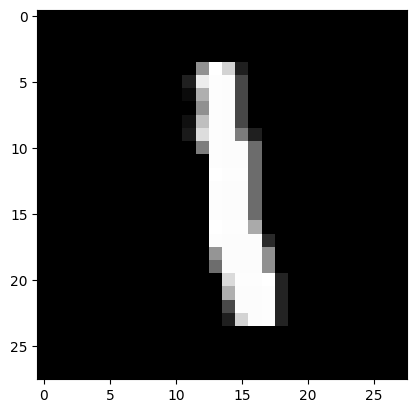

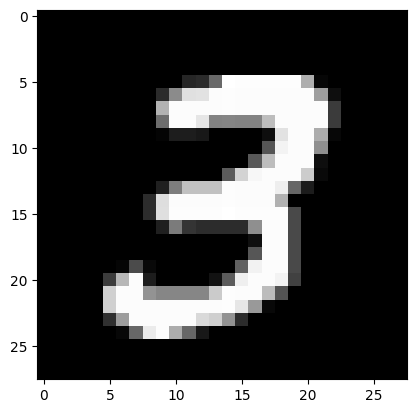

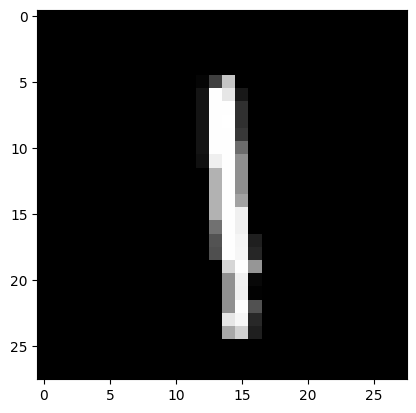

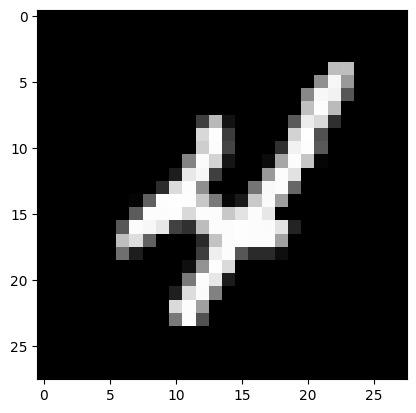

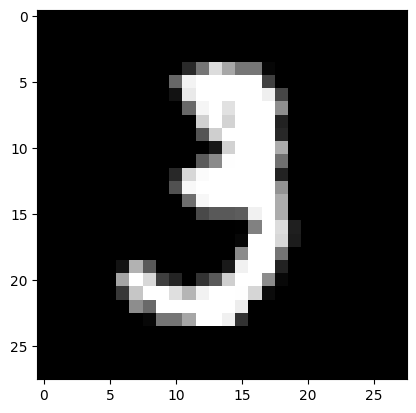

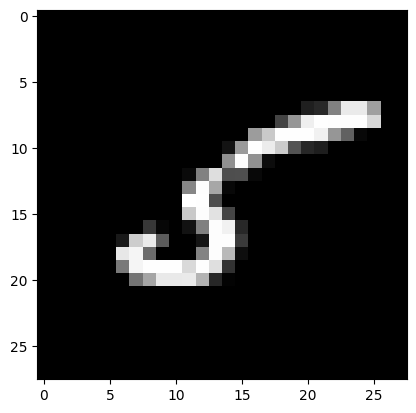

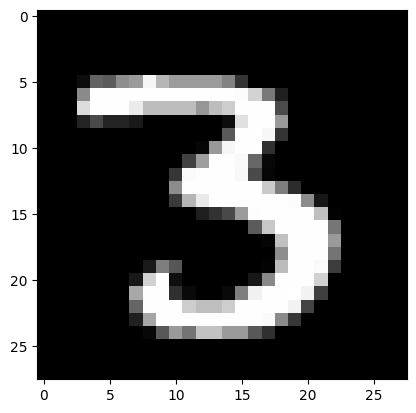

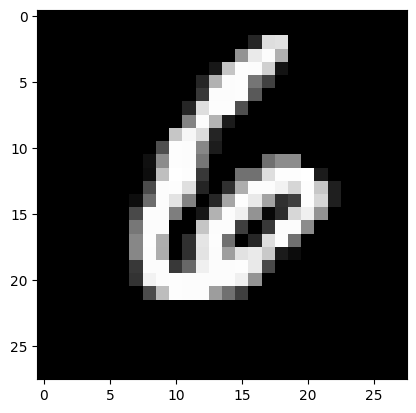

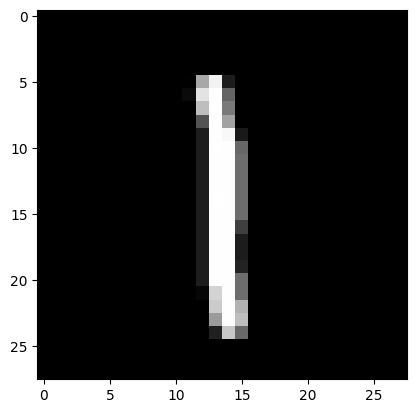

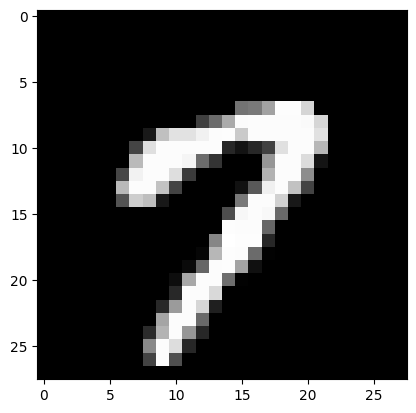

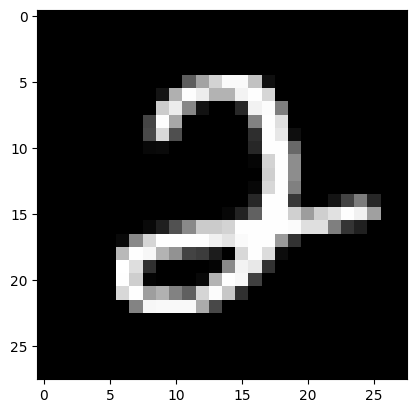

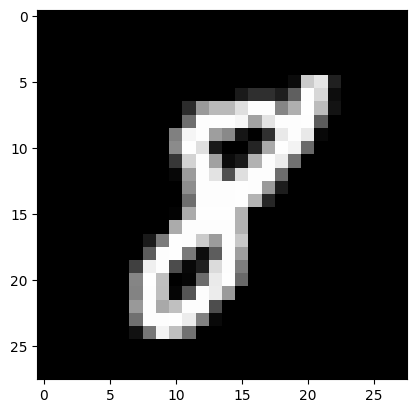

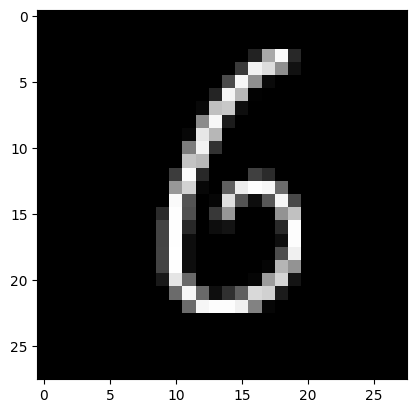

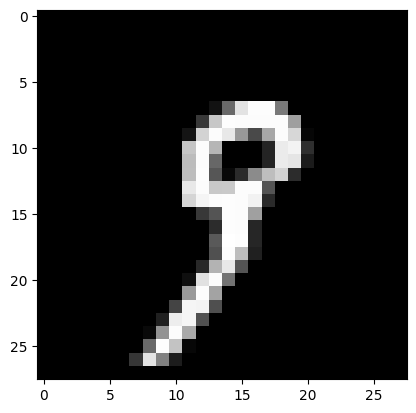

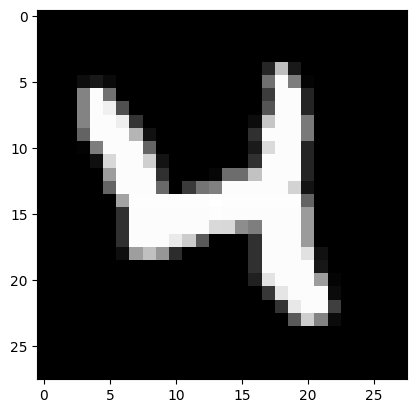

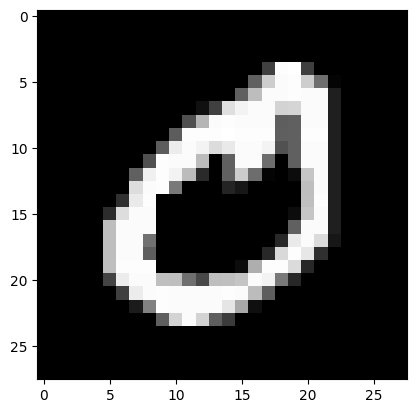

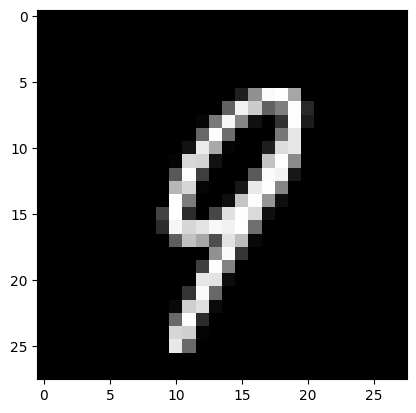

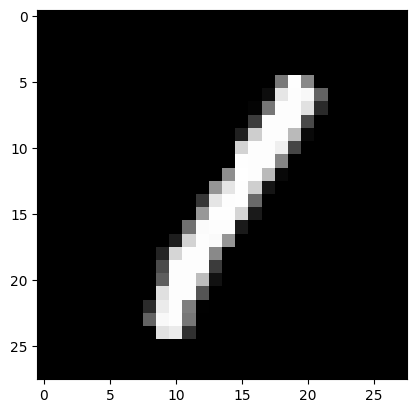

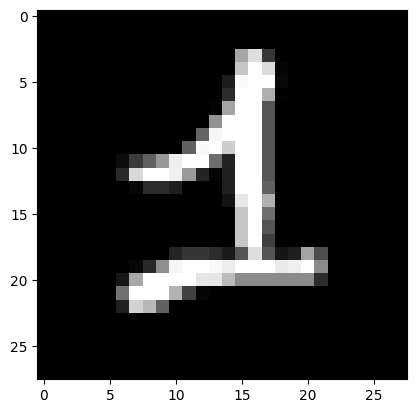

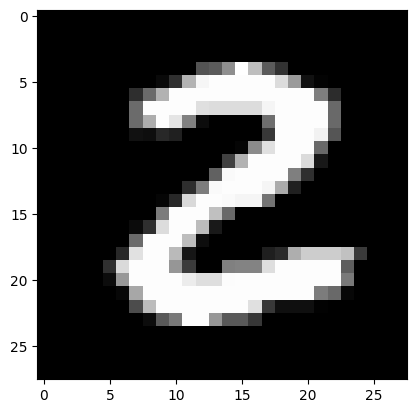

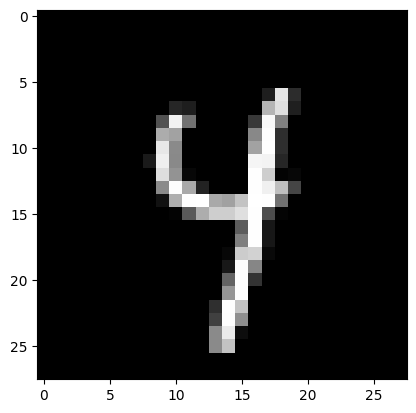

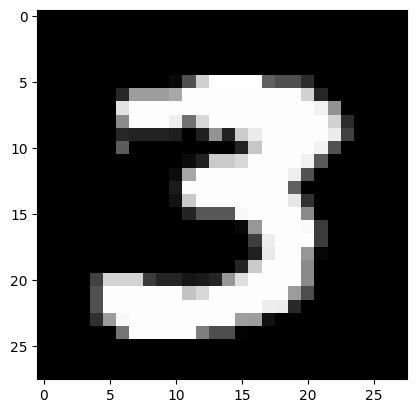

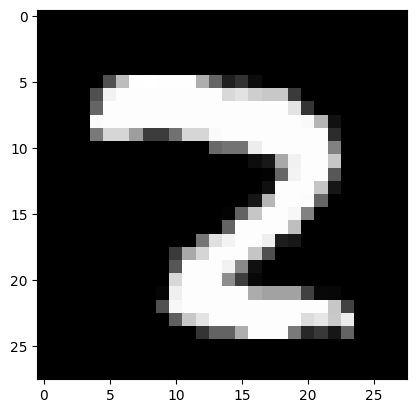

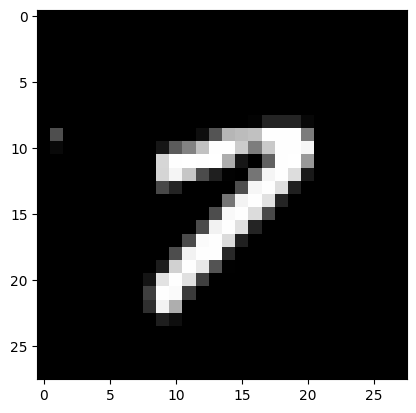

In [15]:

import matplotlib.pyplot as plt
import numpy as np
for i in range(30):
  row=train.iloc[i,1:].to_numpy().reshape(28,28)
  plt.imshow(row,cmap='gray')
  plt.show()






In [47]:
import pandas as pd
import numpy as np

# -----------------------------
# Data
# -----------------------------
train = pd.read_csv('mnist_train.csv')
# first column = label, rest = 784 pixel values
Y_raw = train.iloc[:, 0].values
X = train.iloc[:, 1:].values.astype(np.float64) / 255.0  # normalize to [0,1]

# one-hot encode labels -> shape (N, 10)
num_classes = 10
Y = np.eye(num_classes)[Y_raw]


# -----------------------------
# Helper functions
# -----------------------------
def cal_fanout_fanin(weight_shape):
    fan_in, fan_out = weight_shape
    return fan_in, fan_out


def He_Initialisation(fan_in, fan_out, nonlinearity='relu'):
    gain = np.sqrt(2) if nonlinearity == 'relu' else 1.0
    a = gain * np.sqrt(3 / fan_in)
    return np.random.uniform(low=-a, high=a, size=(fan_in, fan_out))


def bias_param(fan_out):
    # zeros is the standard default for bias init
    return np.full(fan_out,0.1)


def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def softmax(z):
    # subtract row-wise max for numerical stability, sum along axis=1 (per-sample)
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def cross_entropy_loss(Y_true, Y_pred, eps=1e-9):
    m = Y_true.shape[0]
    return -np.sum(Y_true * np.log(Y_pred + eps)) / m


# -----------------------------
# Neural Network
# -----------------------------
class NN:
    def __init__(self, number_of_layers, dim_of_layers, learning_rate=0.0001):
        """
        number_of_layers: int, number of weight layers (e.g. 3 = input->h1->h2->output)
        dim_of_layers: list of dicts, each {'n_in': int, 'n_out': int}
        """
        self.number_of_layers = number_of_layers
        self.dim_of_layers = dim_of_layers
        self.lr = learning_rate
        self.weights = [None] * number_of_layers
        self.biases = [None] * number_of_layers

    def initialisation(self):
        for i in range(self.number_of_layers):
            n_in = self.dim_of_layers[i]['n_in']
            n_out = self.dim_of_layers[i]['n_out']
            self.weights[i] = He_Initialisation(n_in, n_out)
            self.biases[i] = bias_param(n_out)
        return self.weights, self.biases

    def forward_prop(self, X,Y):
        """Runs a full forward pass, caching activations and pre-activations for backprop."""
        self.z_cache = []
        self.a_cache = []
        activation = X
        for i in range(self.number_of_layers):
            z = np.dot(activation, self.weights[i]) + self.biases[i]
            self.z_cache.append(z)
            if i == self.number_of_layers - 1:
                activation = softmax(z)
                self.loss=cross_entropy_loss(Y, activation)

            else:
                activation = relu(z)
            self.a_cache.append(activation)
        return activation

    def backward_prop(self,x, y):
      m=x.shape[0]
      # Unpack the cached values
      z1,  z2,  z3 = self.z_cache
      a1,a2,a3=self.a_cache
      W1,W2,W3=self.weights

    # Layer 3 (softmax + cross-entropy combined shortcut)
      dz3 = a3 - y
      dW3 =  a2.T @ dz3 /m
      db3=np.sum(dz3,axis=0)/m
      da2 =  dz3 @ W3.T

    # Layer 2 (ReLU, 15 units)
      dz2 = da2 * (z2 > 0)
      dW2 = a1.T @ dz2/m
      db2 = np.sum(dz2, axis=0)/m
      da1 = dz2 @ W2.T

    # Layer 1
      dz1 = da1 * (z1 > 0)
      dW1 = x.T @ dz1/m
      db1 = np.sum(dz1, axis=0)/m

      grad_w=[dW1,dW2,dW3]
      grad_b=[db1,db2,db3]
      return grad_w,grad_b

    def update_params(self, grads_w, grads_b):
        for i in range(self.number_of_layers):
            self.weights[i] -= self.lr * grads_w[i]
            self.biases[i] -= self.lr * grads_b[i]

    def training_loop(self,X,Y,epochs=100,batch_size=None,verbose=True):
        m=X.shape[0]
        losses=[]
        for epoch in range(epochs):
            perm = np.random.permutation(m)
            X_shuf, Y_shuf = X[perm], Y[perm]
            epoch_loss = 0
            n_batches = 0
            for start in range(0, m, batch_size):
                end = start + batch_size
                X_batch, Y_batch = X_shuf[start:end], Y_shuf[start:end]
                self.forward_prop(X_batch,Y_batch)
                grad_w,grad_b=self.backward_prop(X_batch, Y_batch)
                self.update_params(grad_w, grad_b)
                epoch_loss += self.loss
                n_batches += 1
            loss = epoch_loss / n_batches
            losses.append(loss)
            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch}: loss = {loss:.4f}")
        return losses






    def predict(self, X,Y):
        y_pred = self.forward_prop(X,Y)
        return np.argmax(y_pred, axis=1)


In [48]:




if __name__ == "__main__":
    dim_of_layers = [
        {'n_in': 784, 'n_out': 25},
        {'n_in': 25, 'n_out': 15},
        {'n_in': 15, 'n_out': 10},
    ]
    X=train.iloc[:,1:].values.astype(np.float64)/255.0
    Y_raw=train.iloc[:,0].values
    Y=np.eye(10)[Y_raw]
    model = NN(number_of_layers=3, dim_of_layers=dim_of_layers, learning_rate=0.1)
    model.initialisation()
    losses = model.training_loop(X, Y, epochs=50, batch_size=32)

    preds = model.predict(X,Y)
    print(preds)
    print(Y_raw)
    accuracy = np.mean(preds == Y_raw)
    print(f"Training accuracy: {accuracy:.4f}")

Epoch 0: loss = 0.3322
Epoch 10: loss = 0.0844
Epoch 20: loss = 0.0635
Epoch 30: loss = 0.0493
Epoch 40: loss = 0.0424
[5 0 4 ... 5 6 8]
[5 0 4 ... 5 6 8]
Training accuracy: 0.9838


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [42]:
model =Sequential(
    [
        Dense(25,activation='relu',input_shape=(784,)),
        Dense(15,activation='relu'),
        Dense(10,activation='softmax')
    ]
)
model.compile(optimizer=Adam(learning_rate=0.0001),loss=tf.keras.losses.CategoricalCrossentropy(),metrics=['accuracy'])
model.fit(X,Y,epochs=50,batch_size=32)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7206 - loss: 1.0594
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8823 - loss: 0.4473
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9072 - loss: 0.3431
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9178 - loss: 0.2977
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9246 - loss: 0.2704
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9298 - loss: 0.2504
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9341 - loss: 0.2349
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9374 - loss: 0.2220
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9401 - loss: 0.2115
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9425 - loss: 0.2024
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9442 - loss: 0.1947
Epoch 12/50
1875/1875 ━━━━━━━━